# Finite Element Method: From Shape Functions to 2D

## Hat Functions, 1D Heat Conduction & Extension to 2D

This notebook builds the Finite Element Method step by step:

| Part | Topic | Key concept |
|------|-------|-------------|
| **I** | Shape functions (hat functions) | P1 linear & P2 quadratic basis |
| **II** | 1D FEM for heat conduction | Assembly of $[K]\{T\} = \{F\}$ |
| **III** | 2D FEM on triangles & quads | Mesh generation, 2D stiffness |

---

## 1 — Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.tri import Triangulation
from matplotlib.collections import PolyCollection

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

---

# Part I — Shape Functions (Hat Functions)

## 2 — Linear Shape Functions (P1)

On a reference element $\xi \in [0, 1]$, two nodes (left, right):

$$N_1(\xi) = 1 - \xi \qquad N_2(\xi) = \xi$$

Any field inside the element is $T(\xi) = T_1 N_1 + T_2 N_2$ — a
straight line between the nodal values.

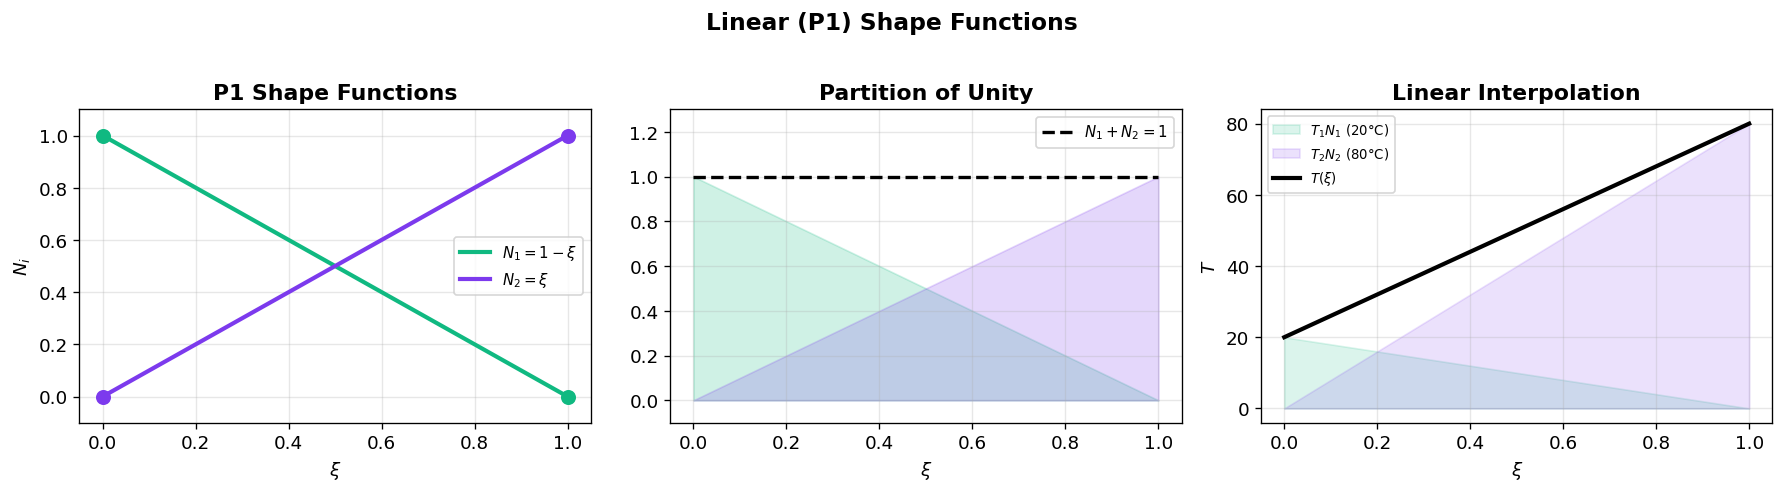

In [2]:
xi = np.linspace(0, 1, 200)

N1_lin = 1 - xi
N2_lin = xi

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Shape functions
ax = axes[0]
ax.plot(xi, N1_lin, color="#10b981", lw=2.5, label="$N_1 = 1 - \\xi$")
ax.plot(xi, N2_lin, color="#7c3aed", lw=2.5, label="$N_2 = \\xi$")
ax.plot([0, 1], [1, 0], "o", color="#10b981", markersize=8)
ax.plot([0, 1], [0, 1], "o", color="#7c3aed", markersize=8)
ax.set_xlabel("$\\xi$"); ax.set_ylabel("$N_i$")
ax.set_title("P1 Shape Functions", fontweight="bold")
ax.legend(fontsize=9); ax.set_ylim(-0.1, 1.1)

# Partition of unity
ax = axes[1]
ax.fill_between(xi, 0, N1_lin, alpha=0.2, color="#10b981")
ax.fill_between(xi, 0, N2_lin, alpha=0.2, color="#7c3aed")
ax.plot(xi, N1_lin + N2_lin, "k--", lw=2, label="$N_1 + N_2 = 1$")
ax.set_xlabel("$\\xi$")
ax.set_title("Partition of Unity", fontweight="bold")
ax.legend(fontsize=9); ax.set_ylim(-0.1, 1.3)

# Interpolation
ax = axes[2]
T1, T2 = 20, 80
ax.fill_between(xi, 0, T1*N1_lin, alpha=0.15, color="#10b981",
                label=f"$T_1 N_1$ ({T1}°C)")
ax.fill_between(xi, 0, T2*N2_lin, alpha=0.15, color="#7c3aed",
                label=f"$T_2 N_2$ ({T2}°C)")
ax.plot(xi, T1*N1_lin + T2*N2_lin, "k-", lw=2.5, label="$T(\\xi)$")
ax.set_xlabel("$\\xi$"); ax.set_ylabel("$T$")
ax.set_title("Linear Interpolation", fontweight="bold")
ax.legend(fontsize=8)

fig.suptitle("Linear (P1) Shape Functions", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

## 3 — Quadratic Shape Functions (P2)

Three nodes (left, mid, right) give parabolic interpolation:

$$
N_1 = (1-\xi)(1-2\xi) \qquad
N_2 = 4\xi(1-\xi) \qquad
N_3 = \xi(2\xi-1)
$$

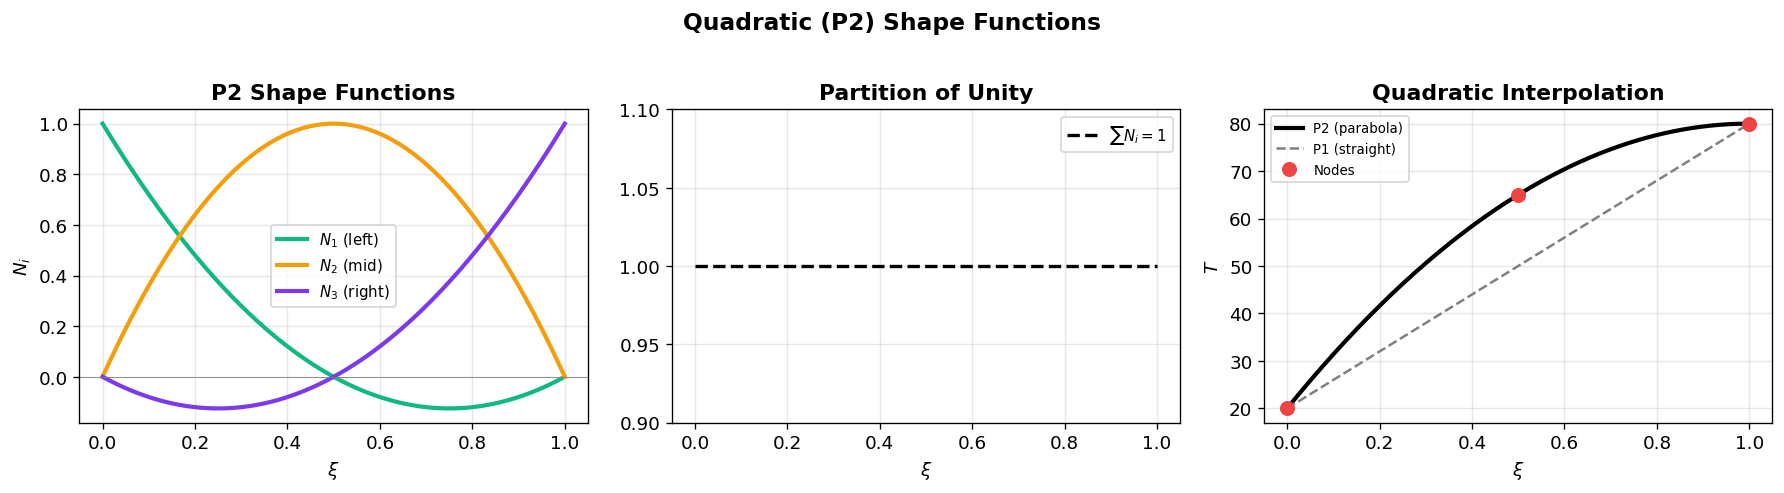

In [3]:
N1_q = (1-xi)*(1-2*xi)
N2_q = 4*xi*(1-xi)
N3_q = xi*(2*xi-1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.plot(xi, N1_q, color="#10b981", lw=2.5, label="$N_1$ (left)")
ax.plot(xi, N2_q, color="#f59e0b", lw=2.5, label="$N_2$ (mid)")
ax.plot(xi, N3_q, color="#7c3aed", lw=2.5, label="$N_3$ (right)")
ax.axhline(0, color="grey", lw=0.5)
ax.set_xlabel("$\\xi$"); ax.set_ylabel("$N_i$")
ax.set_title("P2 Shape Functions", fontweight="bold")
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(xi, N1_q+N2_q+N3_q, "k--", lw=2, label="$\\sum N_i = 1$")
ax.set_xlabel("$\\xi$")
ax.set_title("Partition of Unity", fontweight="bold")
ax.legend(fontsize=9); ax.set_ylim(0.9, 1.1)

ax = axes[2]
T1, T2, T3 = 20, 65, 80
T_q = T1*N1_q + T2*N2_q + T3*N3_q
T_l = T1*(1-xi) + T3*xi
ax.plot(xi, T_q, "k-", lw=2.5, label="P2 (parabola)")
ax.plot(xi, T_l, "--", color="grey", lw=1.5, label="P1 (straight)")
ax.plot([0, 0.5, 1], [T1, T2, T3], "o", color="#ef4444", markersize=8,
        zorder=5, label="Nodes")
ax.set_xlabel("$\\xi$"); ax.set_ylabel("$T$")
ax.set_title("Quadratic Interpolation", fontweight="bold")
ax.legend(fontsize=8)

fig.suptitle("Quadratic (P2) Shape Functions", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

## 4 — Global Hat Functions (Multi-Element)

When elements are assembled, each interior node has a **hat-shaped**
basis function that is nonzero only in the two adjacent elements.

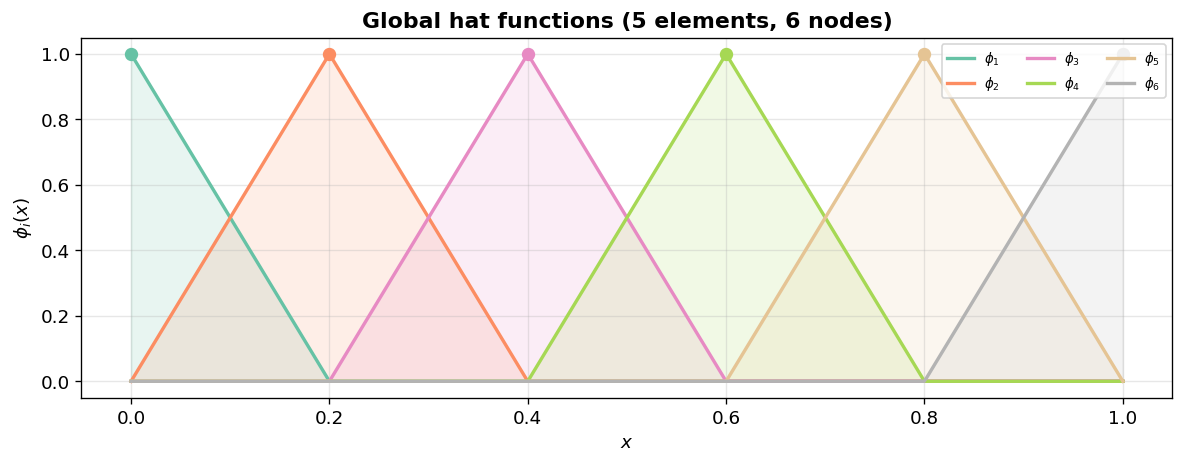

In [4]:
N_elem = 5
nodes = np.linspace(0, 1, N_elem + 1)
x_fine = np.linspace(0, 1, 500)

fig, ax = plt.subplots(figsize=(10, 4))
colors = plt.cm.Set2(np.linspace(0, 1, len(nodes)))

for i, (node, col) in enumerate(zip(nodes, colors)):
    # Build hat function for node i
    phi = np.zeros_like(x_fine)
    for j in range(len(x_fine)):
        x = x_fine[j]
        if i > 0 and nodes[i-1] <= x <= nodes[i]:
            phi[j] = (x - nodes[i-1]) / (nodes[i] - nodes[i-1])
        elif i < len(nodes)-1 and nodes[i] <= x <= nodes[i+1]:
            phi[j] = (nodes[i+1] - x) / (nodes[i+1] - nodes[i])
    ax.fill_between(x_fine, 0, phi, alpha=0.15, color=col)
    ax.plot(x_fine, phi, color=col, lw=2, label=f"$\\phi_{i+1}$")
    ax.plot(node, 1, "o", color=col, markersize=7, zorder=5)

ax.set_xlabel("$x$")
ax.set_ylabel("$\\phi_i(x)$")
ax.set_title(f"Global hat functions ({N_elem} elements, {N_elem+1} nodes)",
             fontweight="bold")
ax.legend(fontsize=8, ncol=3, loc="upper right")
fig.tight_layout()
plt.show()

---

# Part II — 1D Finite Element Method

## 5 — Problem: 1D Heat Conduction

$$-\frac{d}{dx}\!\left(\lambda \frac{dT}{dx}\right) = Q$$

with Dirichlet boundary conditions $T(0) = T_L$, $T(L) = T_R$.

The Galerkin weak form reads:

$$\int_0^L \lambda \frac{dT}{dx}\frac{dv}{dx}\,dx = \int_0^L Q\,v\,dx$$

## 6 — Element Stiffness & Load

For a **linear element** of length $h$:

$$k^e = \frac{\lambda}{h}\begin{bmatrix} 1 & -1 \\ -1 & 1 \end{bmatrix}
\qquad
f^e = \frac{Qh}{2}\begin{bmatrix} 1 \\ 1 \end{bmatrix}$$

For a **quadratic element**:

$$k^e = \frac{\lambda}{3h}\begin{bmatrix} 7 & -8 & 1 \\ -8 & 16 & -8 \\ 1 & -8 & 7 \end{bmatrix}
\qquad
f^e = \frac{Qh}{6}\begin{bmatrix} 1 \\ 4 \\ 1 \end{bmatrix}$$

In [5]:
def fem_1d(N_elem, L=1.0, Q=50.0, T_L=20.0, T_R=80.0,
           lam=1.0, order=1):
    """
    Solve 1D heat conduction  -λ T'' = Q  on [0, L]
    with Dirichlet BCs  T(0) = T_L,  T(L) = T_R.

    order = 1 (linear/P1) or 2 (quadratic/P2).

    Returns: x_nodes, T_nodes, x_fine, T_exact_fine, T_fem_fine
    """
    h = L / N_elem
    total_nodes = N_elem * order + 1
    K = np.zeros((total_nodes, total_nodes))
    F = np.zeros(total_nodes)

    for e in range(N_elem):
        if order == 1:
            idx = [e, e+1]
            ke = (lam/h) * np.array([[1, -1], [-1, 1]])
            fe = Q * h / 2 * np.array([1, 1])
        else:
            idx = [2*e, 2*e+1, 2*e+2]
            ke = (lam/(3*h)) * np.array([[ 7, -8,  1],
                                          [-8, 16, -8],
                                          [ 1, -8,  7]])
            fe = Q * h / 6 * np.array([1, 4, 1])

        for i, ii in enumerate(idx):
            for j, jj in enumerate(idx):
                K[ii, jj] += ke[i, j]
            F[ii] += fe[i]

    # Apply Dirichlet BCs
    F -= K[:, 0] * T_L + K[:, -1] * T_R
    interior = slice(1, total_nodes - 1)
    T_int = np.linalg.solve(K[interior, interior], F[interior])
    T = np.concatenate([[T_L], T_int, [T_R]])

    # Node coordinates
    x_nodes = np.linspace(0, L, total_nodes)

    # Fine interpolation for plotting
    x_fine = np.linspace(0, L, 500)
    T_fem = np.zeros_like(x_fine)
    for k, xf in enumerate(x_fine):
        ei = min(int(xf / (h + 1e-12)), N_elem - 1)
        xi_local = (xf - ei*h) / h
        if order == 1:
            T_fem[k] = T[ei]*(1-xi_local) + T[ei+1]*xi_local
        else:
            T_fem[k] = (T[2*ei]   * (1-xi_local)*(1-2*xi_local)
                      + T[2*ei+1] * 4*xi_local*(1-xi_local)
                      + T[2*ei+2] * xi_local*(2*xi_local-1))

    # Exact solution
    C1 = (T_R - T_L)/L + Q*L/(2*lam)
    T_exact = -Q/(2*lam) * x_fine**2 + C1*x_fine + T_L

    return x_nodes, T, x_fine, T_exact, T_fem

## 7 — Assembly & Solution

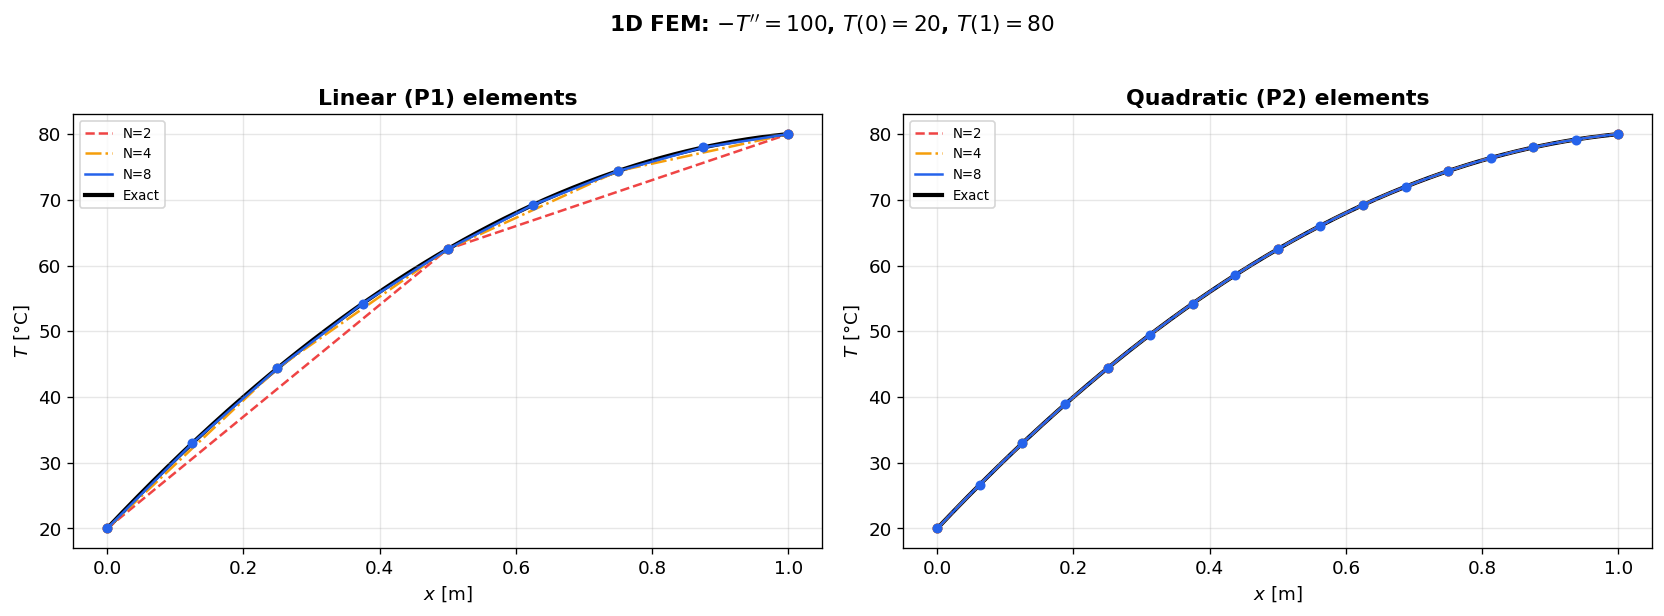

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, order, title in [(axes[0], 1, "Linear (P1)"),
                          (axes[1], 2, "Quadratic (P2)")]:
    for N, col, ls in [(2, "#ef4444", "--"), (4, "#f59e0b", "-."),
                        (8, "#2563eb", "-")]:
        xn, Tn, xf, Te, Tf = fem_1d(N, order=order, Q=100)
        ax.plot(xf, Tf, ls, color=col, lw=1.5, label=f"N={N}")
        ax.plot(xn, Tn, "o", color=col, markersize=5)

    ax.plot(xf, Te, "k-", lw=2.5, label="Exact", zorder=0)
    ax.set_xlabel("$x$ [m]")
    ax.set_ylabel("$T$ [°C]")
    ax.set_title(f"{title} elements", fontweight="bold")
    ax.legend(fontsize=8)

fig.suptitle("1D FEM: $-T'' = 100$, $T(0)=20$, $T(1)=80$",
             fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

## 8 — Convergence: P1 vs P2

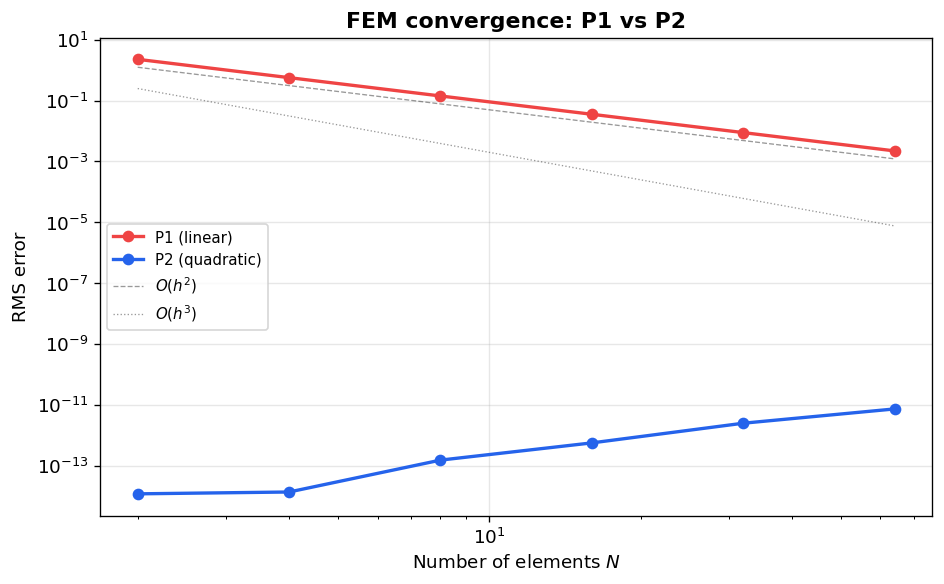

In [7]:
N_values = [2, 4, 8, 16, 32, 64]

fig, ax = plt.subplots(figsize=(8, 5))

for order, col, label in [(1, "#ef4444", "P1 (linear)"),
                           (2, "#2563eb", "P2 (quadratic)")]:
    errors = []
    for N in N_values:
        _, _, xf, Te, Tf = fem_1d(N, order=order, Q=100)
        err = np.sqrt(np.mean((Te - Tf)**2))   # RMS error
        errors.append(err)
    ax.loglog(N_values, errors, "o-", color=col, lw=2,
              markersize=6, label=label)

# Reference slopes
N_ref = np.array(N_values, dtype=float)
ax.loglog(N_ref, 5/N_ref**2, "k--", lw=0.8, alpha=0.4, label="$O(h^2)$")
ax.loglog(N_ref, 2/N_ref**3, "k:",  lw=0.8, alpha=0.4, label="$O(h^3)$")

ax.set_xlabel("Number of elements $N$")
ax.set_ylabel("RMS error")
ax.set_title("FEM convergence: P1 vs P2", fontweight="bold")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## 9 — Visualising the Assembly Process

The global stiffness matrix $[K]$ is built by **stamping** element
matrices into overlapping positions. Shared nodes sum contributions.

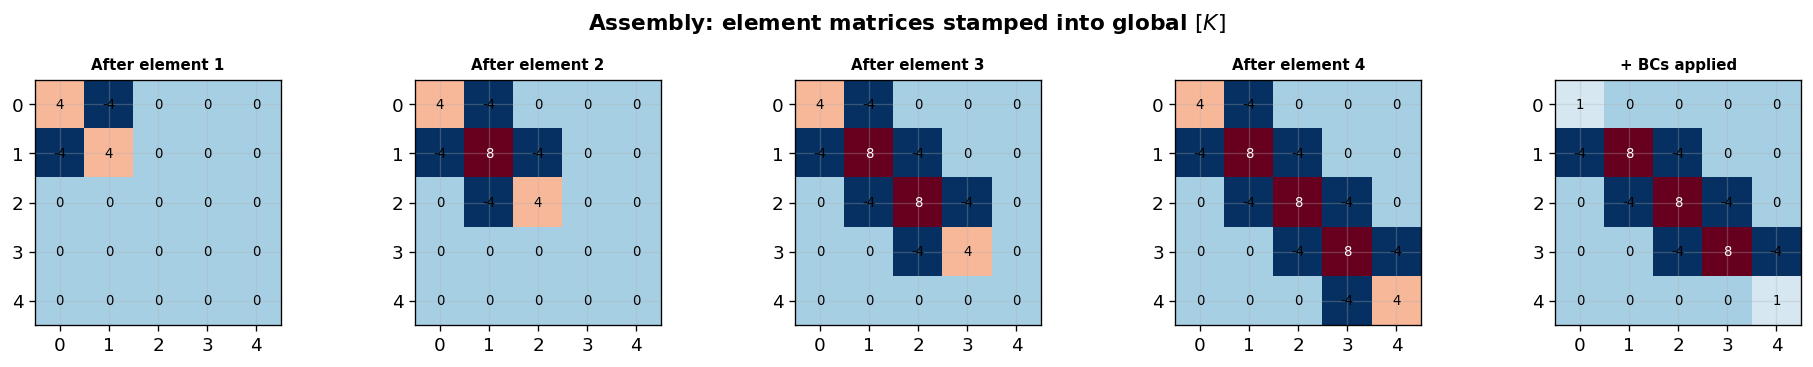

In [8]:
N_elem = 4
h = 1.0 / N_elem
n_nodes = N_elem + 1
K = np.zeros((n_nodes, n_nodes))
ke = np.array([[1, -1], [-1, 1]]) / h

fig, axes = plt.subplots(1, N_elem + 1, figsize=(16, 3))

for e in range(N_elem):
    idx = [e, e+1]
    for i, ii in enumerate(idx):
        for j, jj in enumerate(idx):
            K[ii, jj] += ke[i, j]

    ax = axes[e]
    ax.imshow(K, cmap="RdBu_r", vmin=-1/h, vmax=2/h)
    ax.set_title(f"After element {e+1}", fontsize=9, fontweight="bold")
    ax.set_xticks(range(n_nodes))
    ax.set_yticks(range(n_nodes))
    for i in range(n_nodes):
        for j in range(n_nodes):
            ax.text(j, i, f"{K[i,j]:.0f}", ha="center", va="center",
                    fontsize=8, color="w" if abs(K[i,j]) > 1/h else "k")

# Final with BCs applied
ax = axes[-1]
K_bc = K.copy()
K_bc[0, :] = 0; K_bc[0, 0] = 1
K_bc[-1, :] = 0; K_bc[-1, -1] = 1
ax.imshow(K_bc, cmap="RdBu_r", vmin=-1/h, vmax=2/h)
ax.set_title("+ BCs applied", fontsize=9, fontweight="bold")
ax.set_xticks(range(n_nodes))
ax.set_yticks(range(n_nodes))
for i in range(n_nodes):
    for j in range(n_nodes):
        ax.text(j, i, f"{K_bc[i,j]:.0f}", ha="center", va="center",
                fontsize=8, color="w" if abs(K_bc[i,j]) > 1/h else "k")

fig.suptitle("Assembly: element matrices stamped into global $[K]$",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

---

# Part III — 2D Finite Elements

## 10 — Mesh Generation (Triangles & Quads)

We discretise a rectangular domain into either **triangular** (Tri3)
or **quadrilateral** (Quad4) elements.

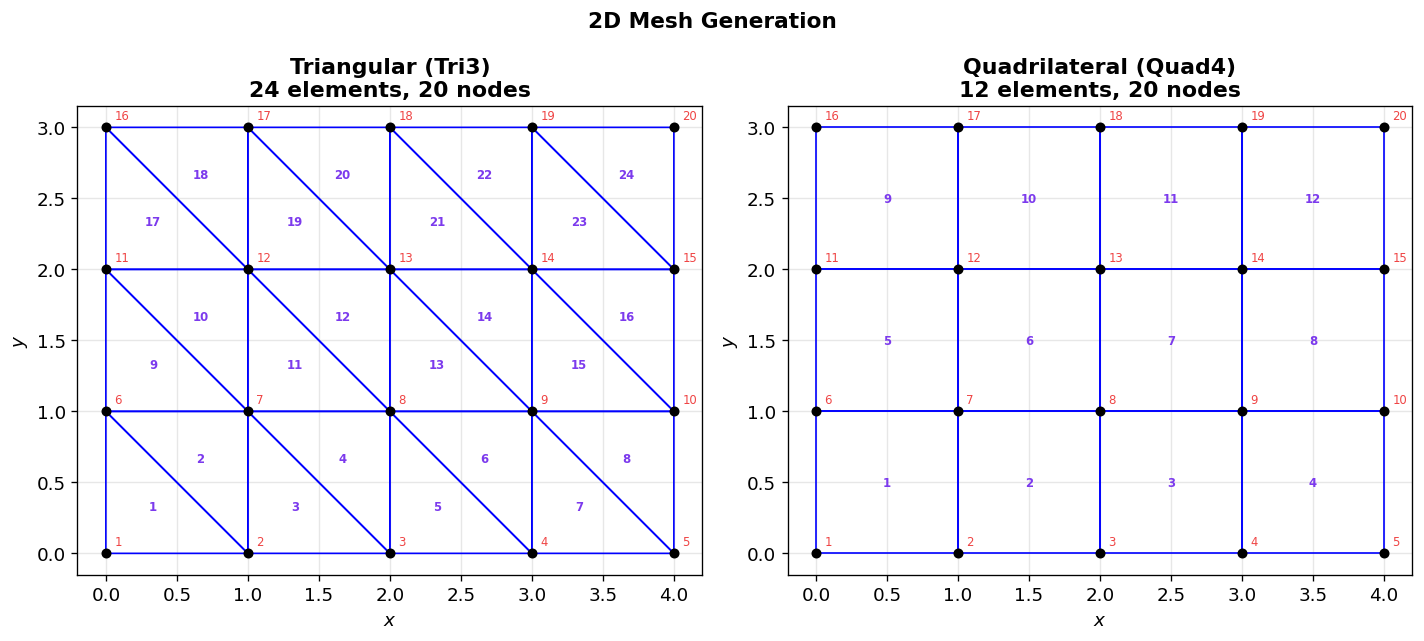

In [9]:
def generate_mesh(rows, cols, elem_type="tri"):
    """
    Generate a structured mesh on [0, cols] x [0, rows].
    Returns: nodes (n×2), elements (list of index arrays).
    """
    nodes = []
    for y in range(rows + 1):
        for x in range(cols + 1):
            nodes.append([x, y])
    nodes = np.array(nodes, dtype=float)

    elements = []
    npc = cols + 1   # nodes per column
    for r in range(rows):
        for c in range(cols):
            n1 = r * npc + c
            n2 = n1 + 1
            n3 = (r+1) * npc + c + 1
            n4 = (r+1) * npc + c
            if elem_type == "quad":
                elements.append([n1, n2, n3, n4])
            else:
                elements.append([n1, n2, n4])
                elements.append([n2, n3, n4])
    return nodes, elements


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, etype, title in [(axes[0], "tri", "Triangular (Tri3)"),
                          (axes[1], "quad", "Quadrilateral (Quad4)")]:
    nodes, elems = generate_mesh(3, 4, etype)

    # Draw elements
    for e in elems:
        poly = nodes[e + [e[0]]]   # close the polygon
        ax.plot(poly[:, 0], poly[:, 1], "b-", lw=1)
        cx = nodes[e, 0].mean()
        cy = nodes[e, 1].mean()
        ax.text(cx, cy, str(elems.index(e)+1), ha="center", va="center",
                fontsize=7, color="#7c3aed", fontweight="bold")

    ax.plot(nodes[:, 0], nodes[:, 1], "ko", markersize=5)
    for i, (x, y) in enumerate(nodes):
        ax.annotate(str(i+1), (x, y), textcoords="offset points",
                    xytext=(5, 5), fontsize=7, color="#ef4444")

    ax.set_aspect("equal")
    ax.set_title(f"{title}\n{len(elems)} elements, {len(nodes)} nodes",
                 fontweight="bold")
    ax.set_xlabel("$x$"); ax.set_ylabel("$y$")

fig.suptitle("2D Mesh Generation", fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

## 11 — 2D FEM: Laplace Equation on a Plate

$$-\nabla^2 T = Q \qquad \text{on } \Omega$$

with Dirichlet BCs on all four edges.

For a **triangular element** with area $A_e$, the stiffness matrix is

$$k^e_{ij} = \frac{1}{4 A_e}
\begin{bmatrix}
b_1 b_1 + c_1 c_1 & b_1 b_2 + c_1 c_2 & b_1 b_3 + c_1 c_3 \\
\cdot & b_2 b_2 + c_2 c_2 & b_2 b_3 + c_2 c_3 \\
\cdot & \cdot & b_3 b_3 + c_3 c_3
\end{bmatrix}
$$

where $b_i, c_i$ are derived from the vertex coordinates.

In [10]:
def fem_2d_tri(rows, cols, Q=10.0,
               bc={"left": 100, "right": 0, "bottom": 50, "top": 0}):
    """
    Solve 2D Laplace/Poisson on a rectangular domain
    using linear triangular elements.
    """
    nodes, elems = generate_mesh(rows, cols, "tri")
    n_nodes = len(nodes)
    K = np.zeros((n_nodes, n_nodes))
    F = np.zeros(n_nodes)

    for e in elems:
        # Triangle vertices
        x1, y1 = nodes[e[0]]
        x2, y2 = nodes[e[1]]
        x3, y3 = nodes[e[2]]

        # Area
        A = 0.5 * abs((x2-x1)*(y3-y1) - (x3-x1)*(y2-y1))
        if A < 1e-15:
            continue

        # Shape function gradients
        b = np.array([y2-y3, y3-y1, y1-y2])
        c = np.array([x3-x2, x1-x3, x2-x1])

        # Element stiffness
        ke = np.zeros((3, 3))
        for i in range(3):
            for j in range(3):
                ke[i, j] = (b[i]*b[j] + c[i]*c[j]) / (4*A)

        # Element load (uniform source)
        fe = Q * A / 3 * np.ones(3)

        # Assemble
        for i in range(3):
            for j in range(3):
                K[e[i], e[j]] += ke[i, j]
            F[e[i]] += fe[i]

    # Identify boundary nodes and apply Dirichlet BCs
    boundary = {}
    for i, (x, y) in enumerate(nodes):
        if x == 0:      boundary[i] = bc["left"]
        elif x == cols:  boundary[i] = bc["right"]
        elif y == 0:     boundary[i] = bc["bottom"]
        elif y == rows:  boundary[i] = bc["top"]

    # Penalty method for BCs
    big = 1e10
    for node_id, val in boundary.items():
        K[node_id, node_id] += big
        F[node_id] += big * val

    T = np.linalg.solve(K, F)
    return nodes, elems, T

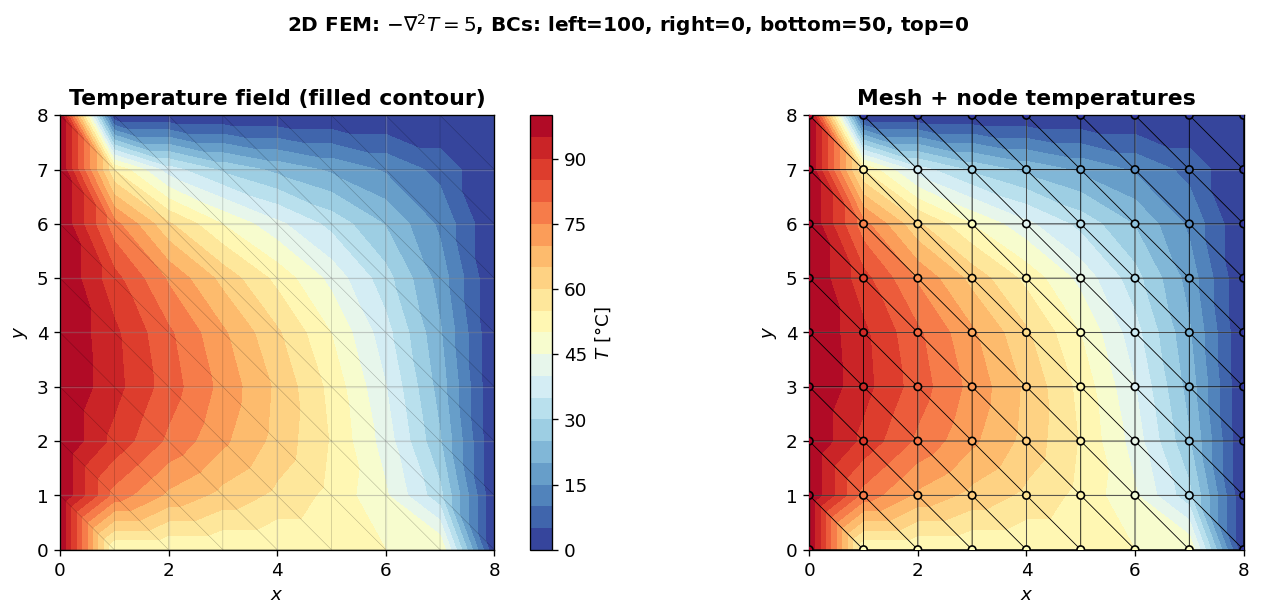

In [11]:
nodes, elems, T = fem_2d_tri(8, 8, Q=5,
    bc={"left": 100, "right": 0, "bottom": 50, "top": 0})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: filled contour
ax = axes[0]
tri = Triangulation(nodes[:, 0], nodes[:, 1],
                     triangles=elems)
tcf = ax.tricontourf(tri, T, levels=20, cmap="RdYlBu_r")
ax.triplot(tri, "k-", lw=0.3, alpha=0.3)
fig.colorbar(tcf, ax=ax, label="$T$ [°C]")
ax.set_aspect("equal")
ax.set_title("Temperature field (filled contour)", fontweight="bold")
ax.set_xlabel("$x$"); ax.set_ylabel("$y$")

# Right: mesh colored by temperature
ax = axes[1]
ax.tricontourf(tri, T, levels=20, cmap="RdYlBu_r")
ax.triplot(tri, "k-", lw=0.5)
ax.scatter(nodes[:, 0], nodes[:, 1], c=T, cmap="RdYlBu_r",
           edgecolors="k", s=20, zorder=5)
ax.set_aspect("equal")
ax.set_title("Mesh + node temperatures", fontweight="bold")
ax.set_xlabel("$x$"); ax.set_ylabel("$y$")

fig.suptitle(
    "2D FEM: $-\\nabla^2 T = 5$, BCs: left=100, right=0, bottom=50, top=0",
    fontsize=12, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

## 12 — Mesh Refinement in 2D

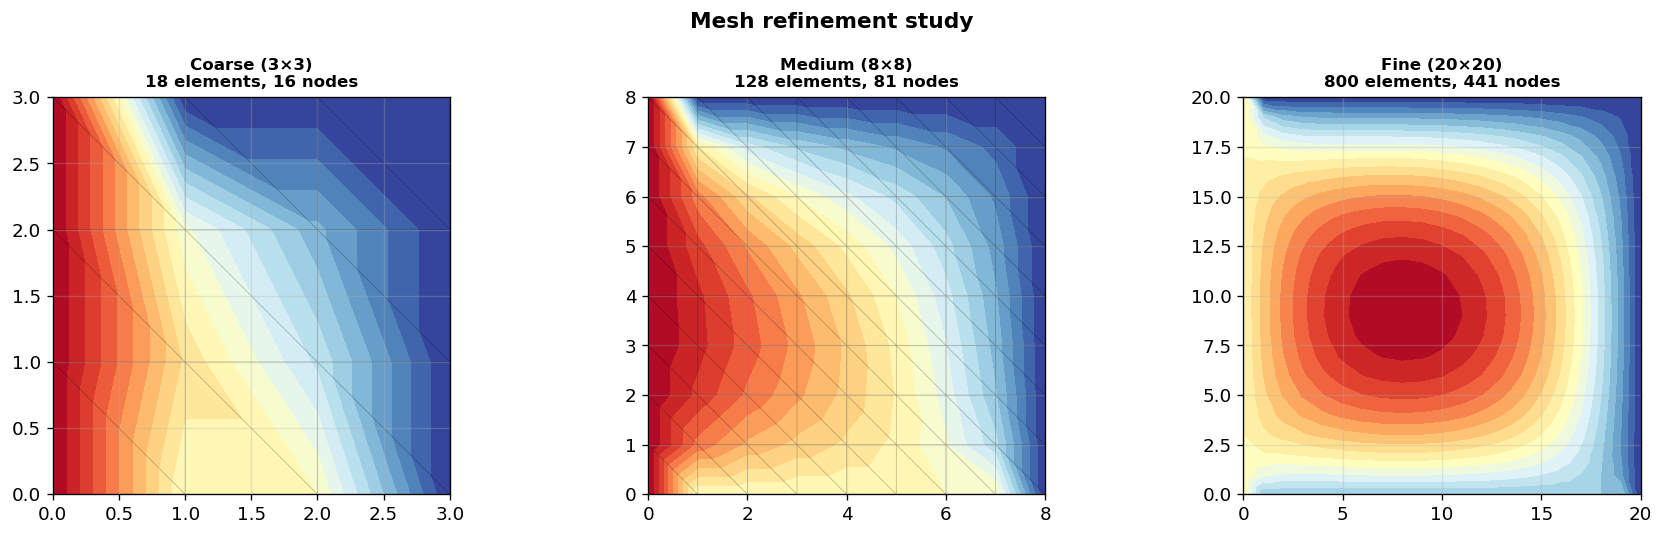

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, n, title in [(axes[0], 3, "Coarse (3×3)"),
                      (axes[1], 8, "Medium (8×8)"),
                      (axes[2], 20, "Fine (20×20)")]:
    nodes, elems, T = fem_2d_tri(n, n, Q=5,
        bc={"left": 100, "right": 0, "bottom": 50, "top": 0})
    tri = Triangulation(nodes[:, 0], nodes[:, 1], triangles=elems)
    ax.tricontourf(tri, T, levels=20, cmap="RdYlBu_r")
    if n <= 8:
        ax.triplot(tri, "k-", lw=0.4, alpha=0.3)
    ax.set_aspect("equal")
    ax.set_title(f"{title}\n{len(elems)} elements, {len(nodes)} nodes",
                 fontweight="bold", fontsize=10)

fig.suptitle("Mesh refinement study", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

## 13 — The Global Stiffness Matrix: Sparsity Pattern

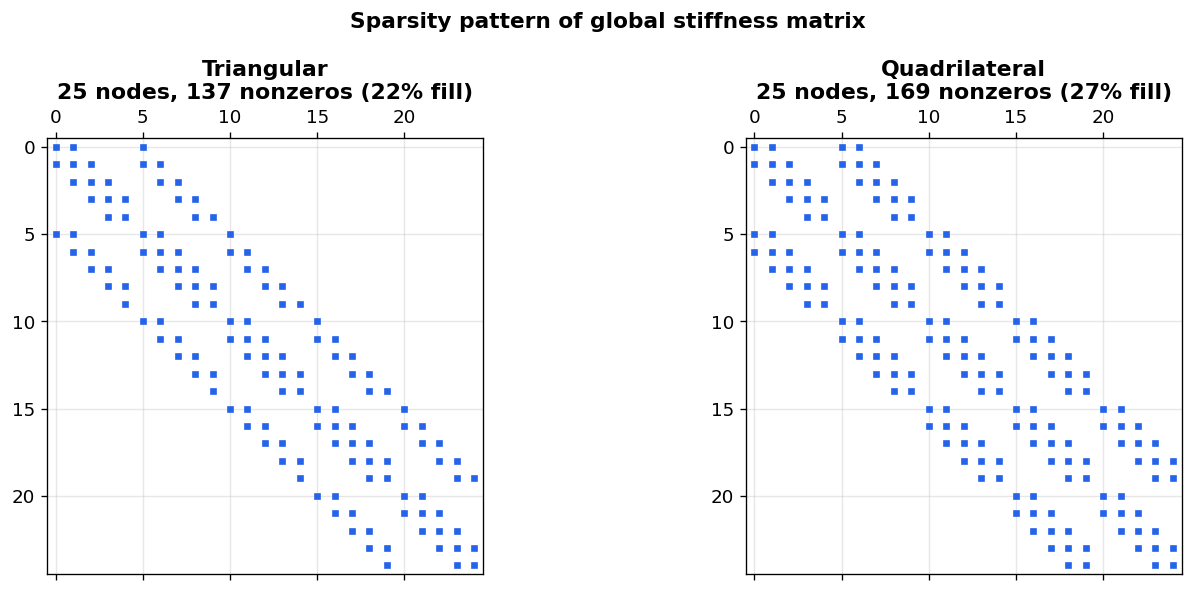

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, etype, title in [(axes[0], "tri", "Triangular"),
                          (axes[1], "quad", "Quadrilateral")]:
    nodes, elems = generate_mesh(4, 4, etype)
    n = len(nodes)
    K = np.zeros((n, n))
    for e in elems:
        for i in e:
            for j in e:
                K[i, j] = 1   # just connectivity

    ax.spy(K, markersize=3, color="#2563eb")
    nnz = np.count_nonzero(K)
    ax.set_title(f"{title}\n{n} nodes, {nnz} nonzeros ({100*nnz/n**2:.0f}% fill)",
                 fontweight="bold")

fig.suptitle("Sparsity pattern of global stiffness matrix",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

## 14 — Notes for Students

### Key take-aways

1. **Shape functions** are the building blocks. Linear (P1) gives
   straight-line interpolation, quadratic (P2) gives parabolas.
   The global "hat functions" are nonzero only in adjacent elements.

2. **Assembly** is the central operation: each element contributes
   a small dense matrix $k^e$ that is stamped into the global
   stiffness matrix $K$. Where elements share nodes, values add up.

3. **P2 converges faster** — $O(h^3)$ vs $O(h^2)$ for P1 — but at
   the cost of larger element matrices (3×3 vs 2×2 in 1D).

4. **2D** extends the same ideas: triangular elements use
   area coordinates, quad elements use bilinear shape functions.
   The stiffness matrix becomes *sparse* with a banded structure.

5. **Boundary conditions** modify the global system. Dirichlet BCs
   fix known values; the penalty method or row elimination are
   common implementation strategies.

### Exercises

1. Modify the 1D solver to support a **non-uniform heat source**
   $Q(x) = 100 \sin(\pi x)$. How does the element load vector change?

2. Add **convective boundary conditions** to the 1D solver:
   $-\lambda dT/dx|_{x=L} = h(T - T_\infty)$. This adds $hA$ to
   the last diagonal entry of $K$.

3. Implement a **Quad4** element stiffness matrix for the 2D solver
   using 2×2 Gauss quadrature.

4. Solve the 2D Poisson equation with $Q=0$ (pure Laplace) and
   compare your FEM result with the analytical series solution.

5. Plot the **condition number** of the global stiffness matrix
   as a function of mesh size. Why does it grow as the mesh is refined?